In [1]:
%run mammo_utils.py

In [2]:
os.environ.setdefault('MAMMO_DATA_ROOT', r'C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16')
print('MAMMO_DATA_ROOT =', os.environ['MAMMO_DATA_ROOT'])

MAMMO_DATA_ROOT = C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16


### <font color='orange'> Preprocessing (/!\skip if done once)

In [3]:
df = collect_png_paths(os.environ['MAMMO_DATA_ROOT'])
df['class'] = df['class'].replace({'normal': 0, 'benign': 1, 'cancer': 1})
print(df.head())
print(f"\nTotal images found: {len(df)}")

                                                path  class
0  C:\Users\Invite\Documents\INRIA\MCDropout\arch...      0
1  C:\Users\Invite\Documents\INRIA\MCDropout\arch...      0
2  C:\Users\Invite\Documents\INRIA\MCDropout\arch...      0
3  C:\Users\Invite\Documents\INRIA\MCDropout\arch...      0
4  C:\Users\Invite\Documents\INRIA\MCDropout\arch...      0

Total images found: 7810


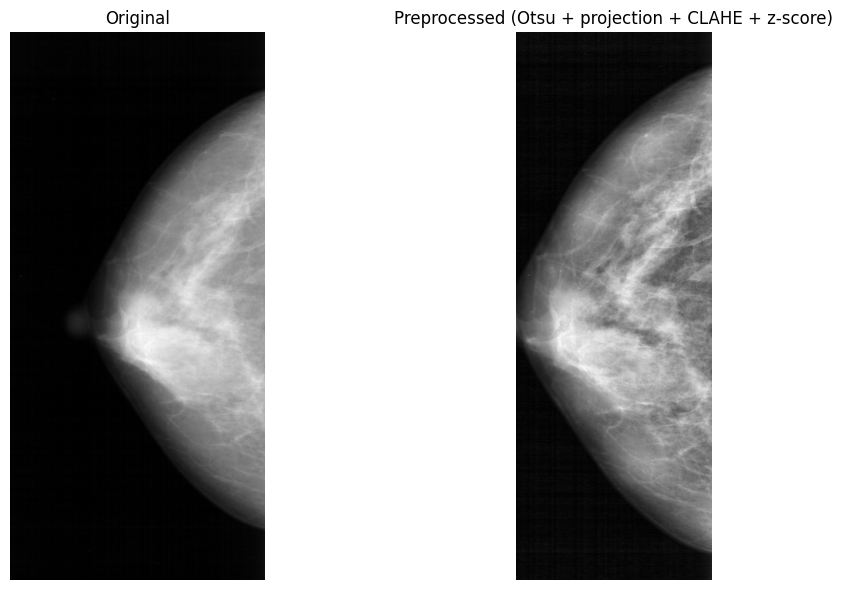

In [7]:
_ = preprocess_and_display_mammogram(df["path"].sample(1).iloc[0])

In [8]:
output_root = os.path.join(os.environ['MAMMO_DATA_ROOT'], 'processed_v3')
preprocessed_df = preprocess_all_mammos(df, output_root, overwrite=False)
preprocessed_df.to_csv("preprocessed_mammos.csv", index=False)


100%|██████████| 7810/7810 [38:29<00:00,  3.38it/s]  


In [4]:
mean, std = compute_mean_std(preprocessed_df.preprocessed_path)
print(f"Dataset mean: {mean}, std: {std}")

100%|██████████| 7810/7810 [04:49<00:00, 27.00it/s]

Dataset mean: [0.26755342], std: [0.24556606]


### <font color='orange'> Loading data for training

In [9]:
mean, std = 0.26755342, 0.24556606

In [10]:
preprocessed_df =  pd.read_csv("preprocessed_mammos.csv")

In [11]:
train_val_df, test_df = train_test_split(preprocessed_df, train_size=0.9, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_val_df, train_size=0.9, test_size=0.1, random_state=42)

In [12]:
train_dataset = MammogramDataset(train_df, mode="train", mean=mean, std=std)
val_dataset = MammogramDataset(val_df, mode="test", mean=mean, std=std)
test_dataset = MammogramDataset(test_df, mode="test", mean=mean, std=std)

train_sampler = custom_sampler(train_dataset)
val_sampler = custom_sampler(val_dataset)
test_sampler = custom_sampler(test_dataset)

train_loader = DataLoader(train_dataset, batch_size=10, sampler=train_sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=10, sampler=val_sampler, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=10, sampler=test_sampler, num_workers=0, pin_memory=True)

### <font color='orange'> Training ResNet-18 for three-classes (normal, benign, cancer) classif. task

In [13]:
model = build_resnet18_grayscale(num_classes=2)

In [14]:
model, history = train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=100,
    lr=5e-4,
    use_amp=True,
    train_info_path="C:/Users/Invite/Documents/INRIA/resnet_training/training_history.pkl",
    ckpts_path="C:/Users/Invite/Documents/INRIA/resnet_training/",
)

Starting epoch 1/100...
training...


100%|██████████| 633/633 [06:42<00:00,  1.57it/s]


validating...


100%|██████████| 71/71 [00:28<00:00,  2.47it/s]


Epoch [1/100] LR=0.000500 | Train loss=0.4908 acc=0.7653 | Val loss=0.9708 acc=0.6529
Starting epoch 2/100...
training...


...

Epoch [99/100] LR=0.000000 | Train loss=0.1181 acc=0.9523 | Val loss=0.6988 acc=0.8293
Starting epoch 100/100...
training...


100%|██████████| 633/633 [06:44<00:00,  1.57it/s]


validating...


100%|██████████| 71/71 [00:28<00:00,  2.48it/s]


Epoch [100/100] LR=0.000000 | Train loss=0.1227 acc=0.9480 | Val loss=0.9457 acc=0.7937


### <font color='orange'> Check perfs on test set

In [15]:
epochs_info = pickle.load(open("C:/Users/Invite/Documents/INRIA/resnet_training/training_history.pkl", "rb"))
epochs_info = pd.DataFrame(epochs_info).sort_values(by=['val_acc','val_loss'], ascending=False)
epochs_info

,epoch,train_loss,train_acc,val_loss,val_acc,lr,ckpt_path
32,33,0.264470,0.875119,0.297336,0.852063,0.000377,C:/Users/Invite/Documents/INRIA/resnet_trainin...
29,30,0.273180,0.873854,0.288234,0.852063,0.000397,C:/Users/Invite/Documents/INRIA/resnet_trainin...
33,34,0.259405,0.876067,0.312396,0.850640,0.000370,C:/Users/Invite/Documents/INRIA/resnet_trainin...
41,42,0.227462,0.896775,0.277693,0.850640,0.000312,C:/Users/Invite/Documents/INRIA/resnet_trainin...
25,26,0.286998,0.856782,0.300481,0.844950,0.000421,C:/Users/Invite/Documents/INRIA/resnet_trainin...
...,...,...,...,...,...,...,...
0,1,0.490764,0.765255,0.970795,0.652916,0.000500,C:/Users/Invite/Documents/INRIA/resnet_trainin...
6,7,0.384323,0.806829,0.712469,0.645804,0.000494,C:/Users/Invite/Documents/INRIA/resnet_trainin...
23,24,0.298315,0.858995,0.893942,0.627312,0.000432,C:/Users/Invite/Documents/INRIA/resnet_trainin...
1,2,0.448830,0.788018,1.772364,0.580370,0.000500,C:/Users/Invite/Documents/INRIA/resnet_trainin...


In [16]:
ckpt_path = 'C:/Users/Invite/Documents/INRIA/resnet_training/epoch_033.pth'

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
model = build_resnet18_grayscale(num_classes=2)
model.load_state_dict(torch.load(ckpt_path)['model_state'])
model = model.to(device)

In [ ]:
# compute accuracy, AUC, PRAUC, max F1.. on test set